# Analiza i predikcija ocena hotelskih recenzija

Ovaj notebook analizira skup od oko 26.700 hotelskih recenzija. Cilj je da se podaci očiste, istraži se njihova struktura kroz EDA, a zatim se obuče i uporede tri različita modela mašinskog učenja koji predviđaju ocenu pojedinačne recenzije (kolona `rating`, opseg 1.0 do 10.0).

**Plan rada:**
1. Učitavanje podataka i osnovni pregled.
2. Audit kvaliteta podataka (NaN, duplikati, tipovi).
3. Čišćenje podataka (uklanjanje nepotrebnih kolona, parsiranje datuma, normalizacija nacionalnosti).
4. Feature engineering (parsiranje tagova, dužina teksta, broj reči).
5. EDA: tabele i grafikoni za razumevanje raspodele i međusobnih odnosa varijabli.
6. Priprema podataka za ML (preprocessing, train/test split).
7. Trening tri modela: linearna regresija, slučajna šuma, gradijentno pojačavanje.
8. Evaluacija i poređenje (MAE, RMSE, R^2, scatter plot, residuali).
9. Fine-tuning najboljeg modela kroz `GridSearchCV`.
10. Sažetak.

**Target varijabla je `rating`** (ocena pojedinačne recenzije), što je kontinualna numerička vrednost u opsegu 1 do 10. Zbog toga je u pitanju problem **regresije**. Kolona `avg_rating` (prosečan rejting hotela) **ne koristi se** kao target jer bi predstavljala curenje informacije.


In [1]:
import ast
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130

TABLE_STYLES = [
    {"selector": "th",
     "props": [("background-color", "#2c3e50"), ("color", "white"),
               ("padding", "10px 14px"), ("text-align", "left"),
               ("font-weight", "600"), ("font-family", "Segoe UI, Arial, sans-serif"),
               ("border", "none")]},
    {"selector": "td",
     "props": [("padding", "8px 14px"),
               ("font-family", "Segoe UI, Arial, sans-serif"),
               ("border-bottom", "1px solid #e0e6ed")]},
    {"selector": "tbody tr:nth-child(even)",
     "props": [("background-color", "#f5f7fa")]},
    {"selector": "tbody tr:hover",
     "props": [("background-color", "#dde6f0")]},
    {"selector": "table",
     "props": [("border-collapse", "collapse"),
               ("border-radius", "6px"), ("overflow", "hidden"),
               ("box-shadow", "0 1px 3px rgba(0,0,0,0.1)"),
               ("margin", "8px 0")]},
]


def styled(df, gradient=None, cmap="Blues", precision=2, hide_index=True):
    s = df.style.set_table_styles(TABLE_STYLES).format(precision=precision, thousands=",")
    if hide_index:
        s = s.hide(axis="index")
    if gradient is not None:
        cols = [gradient] if isinstance(gradient, str) else list(gradient)
        cols = [c for c in cols if c in df.columns]
        if cols:
            s = s.background_gradient(subset=cols, cmap=cmap)
    return s


def pretty_info(df, naslov):
    info_df = pd.DataFrame({
        "#": range(len(df.columns)),
        "Kolona": df.columns,
        "Tip": [str(df[c].dtype) for c in df.columns],
        "Non-null": [f"{df[c].notna().sum():,} / {len(df):,}" for c in df.columns],
        "Jedinstvenih": [f"{df[c].nunique():,}" for c in df.columns],
    })
    mem_kb = df.memory_usage(deep=True).sum() / 1024
    display(Markdown(
        f"**{naslov}**: `{len(df):,}` redova, `{len(df.columns)}` kolona, "
        f"memorija ~`{mem_kb:.1f} KB`"
    ))
    return styled(info_df, hide_index=True)


print("Biblioteke i pomoćne funkcije učitane.")


Biblioteke i pomoćne funkcije učitane.


## 1. Učitavanje podataka

Skup podataka se nalazi u `booking_reviews.csv`. Učitava se u pandas DataFrame, a zatim se prikazuju osnovne dimenzije.

In [2]:
DATA_PATH = Path("booking_reviews.csv")

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
display(Markdown(
    f"Učitan skup `{DATA_PATH.name}` sa **{df_raw.shape[0]:,}** redova "
    f"i **{df_raw.shape[1]}** kolona."
))


Učitan skup `booking_reviews.csv` sa **26,675** redova i **16** kolona.

### 1.1 Pregled kolona

In [3]:
pretty_info(df_raw, "Pregled DataFrame-a df_raw")


**Pregled DataFrame-a df_raw**: `26,675` redova, `16` kolona, memorija ~`66690.1 KB`

#,Kolona,Tip,Non-null,Jedinstvenih
0,index,int64,"26,675 / 26,675","26,675"
1,review_title,object,"26,674 / 26,675","8,960"
2,reviewed_at,object,"26,570 / 26,675","1,240"
3,reviewed_by,object,"26,570 / 26,675","8,566"
4,images,object,"938 / 26,675",755
5,crawled_at,object,"26,386 / 26,675","3,968"
6,url,object,"26,386 / 26,675","1,412"
7,hotel_name,object,"26,386 / 26,675",819
8,hotel_url,object,"26,386 / 26,675",822
9,avg_rating,float64,"26,386 / 26,675",42


In [4]:
display(Markdown("**Prvih 5 redova (skraćeno na ključne kolone)**"))
preview_cols = ["hotel_name", "nationality", "reviewed_at", "rating",
                "avg_rating", "review_title", "tags"]
styled(df_raw[preview_cols].head(5), precision=2)


**Prvih 5 redova (skraćeno na ključne kolone)**

hotel_name,nationality,reviewed_at,rating,avg_rating,review_title,tags
Villa Pura Vida,Poland,11 July 2021,10.00,9.70,Exceptional,Business trip~Solo traveller~Junior Suite~Stayed 1 night~Submitted via mobile
Villa Pura Vida,Belgium,24 November 2019,9.00,9.70,I highly recommend this b&b! We enjoyed it a lot!,Leisure trip~Couple~Deluxe Suite~Stayed 1 night~Submitted via mobile
Hydro Palace Apartment,United Kingdom,3 January 2020,10.00,9.20,Exceptional,Leisure trip~Couple~Apartment with Sea View~Stayed 6 nights~Submitted via mobile
Villa Pura Vida,Netherlands,8 September 2019,10.00,9.70,My stay in the house was a experiencing bliss in luxury. The house is sheer touch of beauty wrapped,Business trip~Solo traveller~Junior Suite~Stayed 4 nights~Submitted via mobile
Hydro Palace Apartment,South Africa,23 June 2019,9.20,9.20,"One bedroom apartment with wonderful view and free, secure parking, but not close enough to the main beach area.",Leisure trip~People with friends~Apartment with Sea View~Stayed 4 nights~Submitted via mobile


**Komentar**: Skup ima 16 kolona koje se mogu grupisati u tri grupe:

- **Identifikacijske:** `index`, `url`, `hotel_url`, `crawled_at`, `images`, `raw_review_text`, `meta`. Ove kolone su tehničke i ne koriste se za modelovanje.
- **Opisne:** `hotel_name`, `nationality`, `reviewed_at`, `reviewed_by`, `review_title`, `review_text`, `tags`.
- **Numeričke:** `rating` (target) i `avg_rating` (prosečan rejting hotela).


## 2. Audit kvaliteta podataka

Pre čišćenja prikazuje se broj NaN vrednosti, duplikata i raspodela target-a.

In [5]:
nan_summary = (
    df_raw.isna().sum().reset_index()
    .rename(columns={"index": "kolona", 0: "broj_nan"})
)
nan_summary["procenat"] = (nan_summary["broj_nan"] / len(df_raw) * 100).round(2)
nan_summary = nan_summary.sort_values("broj_nan", ascending=False)

display(Markdown("**Broj NaN vrednosti po kolonama**"))
styled(nan_summary, gradient=["broj_nan", "procenat"], cmap="Reds", precision=2)


**Broj NaN vrednosti po kolonama**

kolona,broj_nan,procenat
images,"25,737",96.48
raw_review_text,473,1.77
meta,473,1.77
tags,473,1.77
nationality,305,1.14
hotel_name,289,1.08
crawled_at,289,1.08
url,289,1.08
rating,289,1.08
avg_rating,289,1.08


In [6]:
key_cols = ["hotel_name", "reviewed_by", "reviewed_at", "review_text"]
broj_dupli = df_raw.duplicated(subset=key_cols).sum()

display(Markdown("**Statistika ciljne varijable `rating`**"))
target_stat = df_raw["rating"].describe().round(3).reset_index()
target_stat.columns = ["metrika", "vrednost"]
styled(target_stat, gradient="vrednost", cmap="Blues", precision=3)


**Statistika ciljne varijable `rating`**

metrika,vrednost
count,"26,386.000"
mean,8.561
std,1.567
min,1.000
25%,7.900
50%,9.000
75%,10.000
max,10.000


In [7]:
display(Markdown(
    f"- Broj redova: **{len(df_raw):,}**  \n"
    f"- Broj duplikata po `(hotel, korisnik, datum, tekst)`: **{broj_dupli}**  \n"
    f"- Broj redova bez vrednosti `rating` (target): **{df_raw['rating'].isna().sum()}**  \n"
    f"- Jedinstvenih hotela: **{df_raw['hotel_name'].nunique():,}**  \n"
    f"- Jedinstvenih nacionalnosti: **{df_raw['nationality'].nunique():,}**"
))


- Broj redova: **26,675**  
- Broj duplikata po `(hotel, korisnik, datum, tekst)`: **139**  
- Broj redova bez vrednosti `rating` (target): **289**  
- Jedinstvenih hotela: **819**  
- Jedinstvenih nacionalnosti: **163**

**Komentar**: Većina kolona ima visok procenat popunjenosti. Kolona `images` je gotovo prazna (oko 96% NaN) jer korisnici retko prilažu slike. Ova kolona se uklanja. Ciljna varijabla `rating` je dostupna za 26.386 redova (99% skupa). Distribucija je pomerena ka visokim ocenama (medijana 9.0, prosek 8.56), što je tipično za hotelske recenzije.

## 3. Čišćenje podataka

Sledeći koraci se primenjuju na sirov skup podataka:
1. **Uklanjanje tehničkih kolona** koje nemaju značaj za predikciju (`url`, `hotel_url`, `images`, `raw_review_text`, `crawled_at`, `index`, `meta`).
2. **Uklanjanje redova bez ciljne vrednosti** (`rating` je NaN).
3. **Uklanjanje duplikata** po kombinaciji (hotel, korisnik, datum, tekst).
4. **Parsiranje datuma** `reviewed_at` u `datetime`, dodavanje izvedenih kolona `review_year`, `review_month`.
5. **Normalizacija `nationality`**: top N najfrekventnijih nacionalnosti se zadržava, ostale se grupišu u kategoriju `Other`.
6. **Popunjavanje praznih tekstova**: NaN u `review_text`, `review_title`, `tags` zamenjuje se praznim stringom (jer je odsustvo teksta validna informacija).


In [8]:
df = df_raw.copy()

drop_cols = ["url", "hotel_url", "images", "raw_review_text",
             "crawled_at", "index", "meta", "reviewed_by"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
display(Markdown(f"Uklonjeno **{len(drop_cols)}** tehničkih kolona."))

before = len(df)
df = df.dropna(subset=["rating"])
display(Markdown(f"Uklonjeno **{before - len(df)}** redova bez vrednosti `rating`."))

before = len(df)
df = df.drop_duplicates(subset=["hotel_name", "reviewed_at", "review_text"])
display(Markdown(f"Uklonjeno **{before - len(df)}** duplikata."))

df["reviewed_dt"] = pd.to_datetime(df["reviewed_at"], errors="coerce", format="%d %B %Y")
df["review_year"] = df["reviewed_dt"].dt.year
df["review_month"] = df["reviewed_dt"].dt.month
display(Markdown(
    f"Datum `reviewed_at` parsiran u datetime: uspešno za "
    f"**{df['reviewed_dt'].notna().sum():,} / {len(df):,}** redova."
))

TOP_N_NAT = 15
top_nat = df["nationality"].value_counts().head(TOP_N_NAT).index.tolist()
df["nationality_clean"] = df["nationality"].where(
    df["nationality"].isin(top_nat), other="Other"
).fillna("Other")
display(Markdown(
    f"Nacionalnost svedena na top **{TOP_N_NAT}** kategorija + `Other`."
))

for col in ["review_text", "review_title", "tags"]:
    df[col] = df[col].fillna("")

display(Markdown(f"\nNakon čišćenja: **{len(df):,}** redova, **{df.shape[1]}** kolona."))


Uklonjeno **8** tehničkih kolona.

Uklonjeno **289** redova bez vrednosti `rating`.

Uklonjeno **567** duplikata.

Datum `reviewed_at` parsiran u datetime: uspešno za **25,819 / 25,819** redova.

Nacionalnost svedena na top **15** kategorija + `Other`.


Nakon čišćenja: **25,819** redova, **12** kolona.

## 4. Feature engineering

Iz postojećih kolona izvode se nove varijable koje će modelima biti korisne:

- **`text_length`**, **`title_length`**: dužina teksta i naslova u karakterima. Duže recenzije često nose više informacija o iskustvu, pa može postojati veza između dužine i ocene.
- **`word_count`**: broj reči u tekstu recenzije.
- **`stay_nights`**: broj noćenja, izvučen regularnim izrazom iz `tags` (npr. "Stayed 3 nights" daje 3).
- **`trip_type`**: tip putovanja (`Leisure trip`, `Business trip`, `Other`), izdvojeno iz tagova.
- **`traveler_type`**: tip putnika (`Solo traveller`, `Couple`, `Family with young children`, `Group`, `People with friends`, `With a pet`, `Other`).
- **`via_mobile`**: binarni indikator da li je recenzija submitovana sa mobilnog uređaja.

Ovaj korak transformiše neuređeni tekst tagova u strukturirane numeričke i kategoričke varijable koje algoritmi mogu da koriste.

In [9]:
TRIP_TYPES = {"Leisure trip", "Business trip"}
TRAVELER_TYPES = {
    "Solo traveller", "Couple", "Family with young children",
    "Group", "People with friends", "With a pet",
    "Family with older children",
}
NIGHTS_RE = re.compile(r"Stayed\s+(\d+)\s+night")


def parse_tags(tag_str):
    parts = [p.strip() for p in str(tag_str).split("~") if p.strip()]
    trip = next((p for p in parts if p in TRIP_TYPES), "Other")
    traveler = next((p for p in parts if p in TRAVELER_TYPES), "Other")
    via_mobile = int(any("mobile" in p.lower() for p in parts))
    nights = None
    for p in parts:
        m = NIGHTS_RE.search(p)
        if m:
            nights = int(m.group(1))
            break
    return pd.Series({
        "trip_type": trip,
        "traveler_type": traveler,
        "via_mobile": via_mobile,
        "stay_nights": nights,
    })


df_tags = df["tags"].apply(parse_tags)
df = pd.concat([df, df_tags], axis=1)

df["text_length"] = df["review_text"].str.len()
df["title_length"] = df["review_title"].str.len()
df["word_count"] = df["review_text"].str.split().str.len().fillna(0).astype(int)
df["stay_nights"] = df["stay_nights"].fillna(df["stay_nights"].median())

display(Markdown("**Pregled novih varijabli (prvih 5 redova)**"))
new_cols = ["trip_type", "traveler_type", "via_mobile", "stay_nights",
            "text_length", "title_length", "word_count"]
styled(df[new_cols].head(5), gradient=["text_length", "word_count"],
       cmap="YlGnBu", precision=1)


**Pregled novih varijabli (prvih 5 redova)**

trip_type,traveler_type,via_mobile,stay_nights,text_length,title_length,word_count
Business trip,Solo traveller,1,1.0,51,11,8
Leisure trip,Couple,1,1.0,41,49,6
Leisure trip,Couple,1,6.0,136,11,24
Business trip,Solo traveller,1,4.0,212,99,38
Leisure trip,People with friends,1,4.0,703,113,120


In [10]:
display(Markdown("**Statistika izvedenih numeričkih varijabli**"))
fe_stat = df[["stay_nights", "text_length", "title_length", "word_count",
              "via_mobile"]].describe().round(2).reset_index()
fe_stat.columns = ["metrika"] + list(fe_stat.columns[1:])
styled(fe_stat, gradient=fe_stat.columns[1:].tolist(), cmap="YlGnBu", precision=2)


**Statistika izvedenih numeričkih varijabli**

metrika,stay_nights,text_length,title_length,word_count,via_mobile
count,"25,819.00","25,819.00","25,819.00","25,819.00","25,819.00"
mean,1.98,164.41,18.96,28.96,0.66
std,1.51,203.80,20.46,37.40,0.47
min,1.00,2.00,0.00,1.00,0.00
25%,1.00,47.00,8.00,8.00,0.00
50%,2.00,84.00,11.00,14.00,1.00
75%,2.00,210.00,22.00,37.00,1.00
max,30.00,"3,368.00",120.00,614.00,1.00


**Komentar**: Tipična recenzija ima oko 80 karaktera (medijana) i traje 1-2 noći (medijana 2). Većina recenzija je submitovana sa mobilnog uređaja.

## 5. Eksplorativna analiza (EDA)

EDA služi da se prepoznaju obrasci u podacima pre nego što se obuče modeli. Za potrebe ovog rada prikazane su tri sumarne tabele i pet grafikona koji oslikavaju glavne karakteristike skupa.

### 5.1 Distribucija ocena (rating)

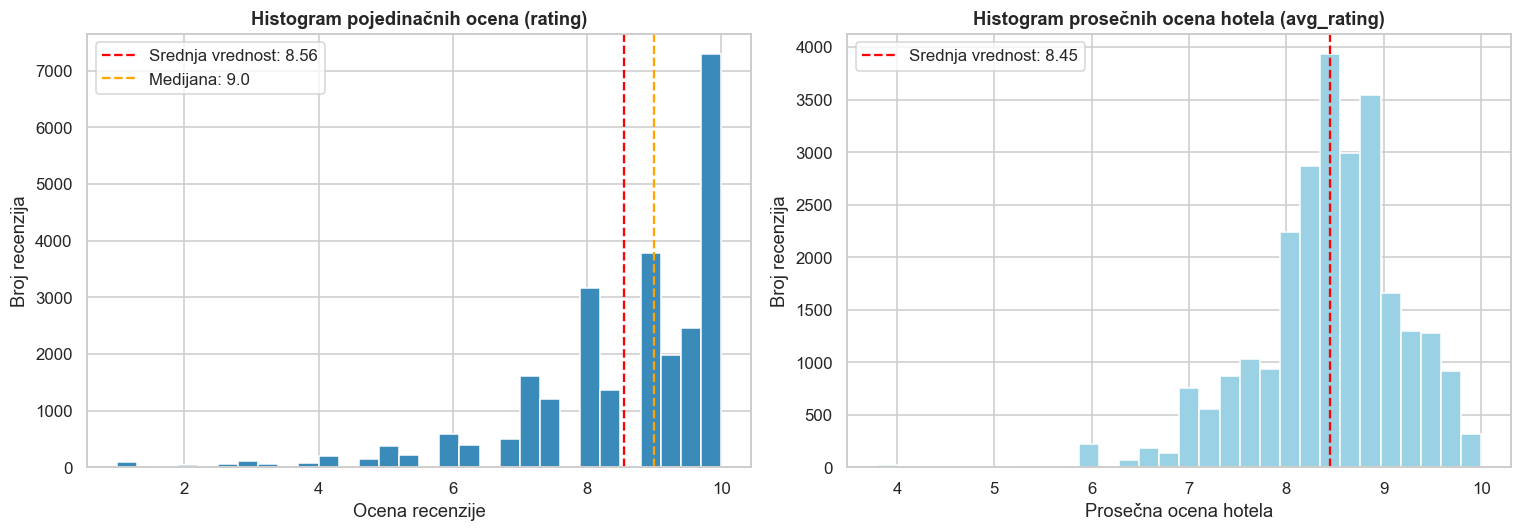

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["rating"], bins=30, color="#3b8bba", edgecolor="white")
axes[0].axvline(df["rating"].mean(), color="red", linestyle="--",
                label=f"Srednja vrednost: {df['rating'].mean():.2f}")
axes[0].axvline(df["rating"].median(), color="orange", linestyle="--",
                label=f"Medijana: {df['rating'].median():.1f}")
axes[0].set_title("Histogram pojedinačnih ocena (rating)", fontweight="bold")
axes[0].set_xlabel("Ocena recenzije")
axes[0].set_ylabel("Broj recenzija")
axes[0].legend()

axes[1].hist(df["avg_rating"], bins=30, color="#9bd1e5", edgecolor="white")
axes[1].axvline(df["avg_rating"].mean(), color="red", linestyle="--",
                label=f"Srednja vrednost: {df['avg_rating'].mean():.2f}")
axes[1].set_title("Histogram prosečnih ocena hotela (avg_rating)", fontweight="bold")
axes[1].set_xlabel("Prosečna ocena hotela")
axes[1].set_ylabel("Broj recenzija")
axes[1].legend()

plt.tight_layout()
plt.show()


**Komentar**: Distribucija ocena je izrazito pomerena ka visokim vrednostima. Medijana je 9.0, a oko 75% svih ocena je 7.9 ili više. Ovo je tipično za hotelske recenzije, jer korisnici češće ostavljaju komentare kada su zadovoljni. Distribucija prosečnih ocena hotela (`avg_rating`) je manje raspršena (standardna devijacija ~0.7), jer agregira ocene više korisnika.

### 5.2 Tabela 1: Top 15 nacionalnosti po broju recenzija i prosečnoj oceni

In [12]:
nat_stat = (
    df.groupby("nationality_clean")
    .agg(broj_recenzija=("rating", "size"),
         prosecan_rating=("rating", "mean"),
         medijana_rating=("rating", "median"))
    .sort_values("broj_recenzija", ascending=False)
    .head(15)
    .round(2)
    .reset_index()
    .rename(columns={"nationality_clean": "nacionalnost"})
)

display(Markdown("**Top 15 nacionalnosti**"))
styled(nat_stat, gradient=["broj_recenzija", "prosecan_rating"],
       cmap="Blues", precision=2)


**Top 15 nacionalnosti**

nacionalnost,broj_recenzija,prosecan_rating,medijana_rating
United Kingdom,"6,610",8.72,9.20
Other,"5,912",8.47,9.00
Belgium,"4,297",8.51,9.00
Netherlands,"2,016",8.26,8.80
Germany,"1,276",8.40,9.00
United States,"1,153",8.90,9.60
France,680,8.50,9.00
Ireland,613,8.63,9.00
Australia,551,8.81,9.20
Italy,501,8.37,8.80


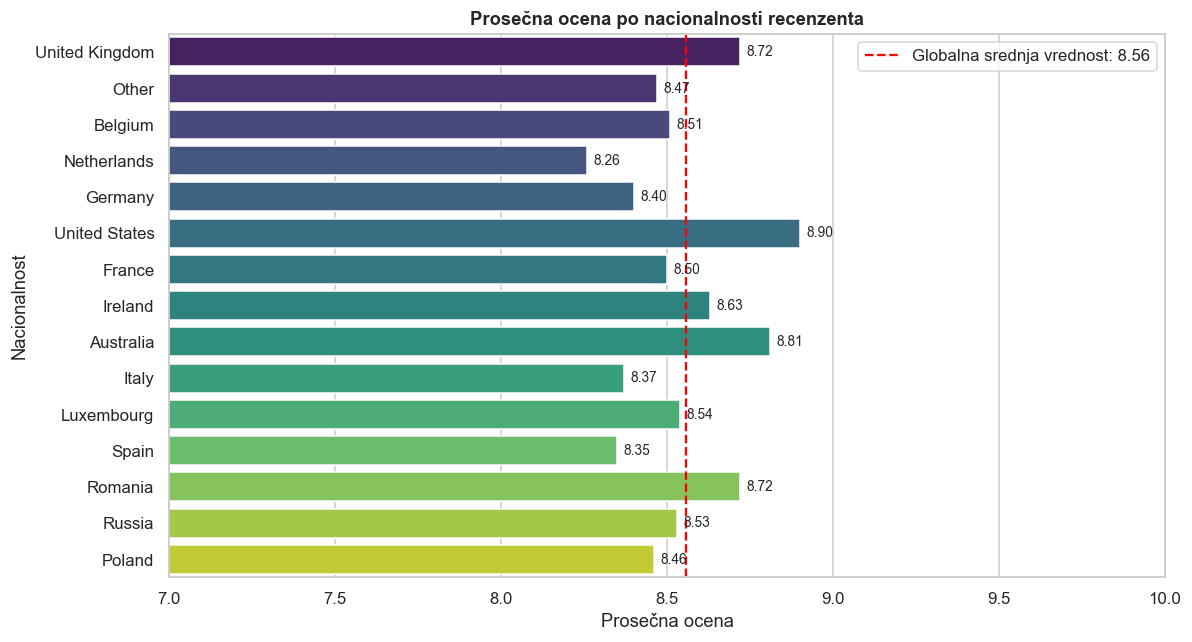

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=nat_stat, y="nacionalnost", x="prosecan_rating",
    hue="nacionalnost", palette="viridis", legend=False, ax=ax,
)
ax.axvline(df["rating"].mean(), color="red", linestyle="--",
           label=f"Globalna srednja vrednost: {df['rating'].mean():.2f}")
ax.set_title("Prosečna ocena po nacionalnosti recenzenta",
             fontweight="bold")
ax.set_xlabel("Prosečna ocena")
ax.set_ylabel("Nacionalnost")
ax.set_xlim(7, 10)
ax.legend()
for i, v in enumerate(nat_stat["prosecan_rating"]):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


**Komentar**: Najveći broj recenzija dolazi iz Velike Britanije, Belgije i Holandije. Među nacionalnostima sa najmanje 200 recenzija razlike u proseku nisu velike, kreću se uglavnom u opsegu 8.3 do 8.9. To pokazuje da nacionalnost sama po sebi nije snažan prediktor, ali i dalje može poneti suptilnu varijabilnost.

### 5.3 Tabela 2: Distribucija po tipu putovanja i tipu putnika

In [14]:
trip_traveler = (
    df.groupby(["trip_type", "traveler_type"])
    .agg(broj=("rating", "size"),
         prosek=("rating", "mean"))
    .round(2)
    .reset_index()
    .sort_values("broj", ascending=False)
    .head(15)
)

display(Markdown("**Top 15 kombinacija (tip putovanja, tip putnika)**"))
styled(trip_traveler, gradient=["broj", "prosek"], cmap="PuBu", precision=2)


**Top 15 kombinacija (tip putovanja, tip putnika)**

trip_type,traveler_type,broj,prosek
Leisure trip,Couple,"8,514",8.70
Leisure trip,Family with young children,"4,532",8.58
Business trip,Solo traveller,"3,794",8.33
Leisure trip,Solo traveller,"2,932",8.46
Leisure trip,Group,"2,020",8.58
Leisure trip,People with friends,"1,267",8.71
Business trip,Group,769,8.32
Business trip,Couple,524,8.38
Other,Solo traveller,285,8.27
Other,Couple,247,8.46


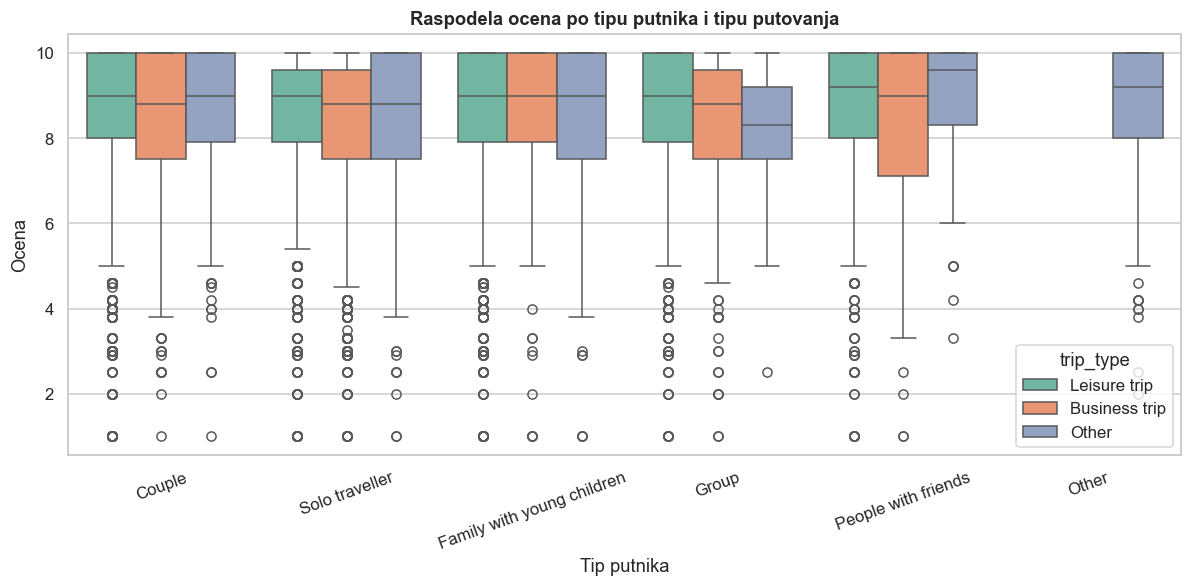

In [15]:
fig, ax = plt.subplots(figsize=(11, 5.5))
order_trip = df["trip_type"].value_counts().index.tolist()
order_trav = df["traveler_type"].value_counts().head(6).index.tolist()
sns.boxplot(
    data=df[df["traveler_type"].isin(order_trav)],
    x="traveler_type", y="rating", hue="trip_type",
    order=order_trav, hue_order=order_trip, palette="Set2", ax=ax,
)
ax.set_title("Raspodela ocena po tipu putnika i tipu putovanja",
             fontweight="bold")
ax.set_xlabel("Tip putnika")
ax.set_ylabel("Ocena")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Komentar**: Najveći broj recenzija odnosi se na parove na odmoru (Couple, Leisure trip). Solo putnici na poslovnim putovanjima takođe čine veliki segment. Svi tipovi putnika imaju medijanu oko 9, ali tipovi sa manjim brojem zapažanja (npr. With a pet) imaju veću varijabilnost.

### 5.4 Tabela 3: Top 10 hotela po broju recenzija

In [16]:
top_hotels = (
    df.groupby("hotel_name")
    .agg(broj_recenzija=("rating", "size"),
         prosecan_rating=("rating", "mean"),
         avg_rating_hotela=("avg_rating", "first"))
    .sort_values("broj_recenzija", ascending=False)
    .head(10)
    .round(2)
    .reset_index()
)

display(Markdown("**Top 10 hotela po broju recenzija**"))
styled(top_hotels, gradient=["broj_recenzija", "prosecan_rating", "avg_rating_hotela"],
       cmap="Greens", precision=2)


**Top 10 hotela po broju recenzija**

hotel_name,broj_recenzija,prosecan_rating,avg_rating_hotela
Motel One Brussels,761,8.98,8.90
Marivaux Hotel,395,8.51,8.50
Snuffel Hostel,367,8.97,8.80
Hostel Bruegel,349,8.46,8.40
nhow Brussels Bloom,321,8.31,8.30
NH Brussels EU Berlaymont,319,8.50,8.50
Hygge Hotel,285,8.68,8.60
Novotel Brussels City Centre,275,8.54,8.50
Jam Hotel,266,7.95,8.00
Thon Hotel Brussels City Centre,256,8.27,8.30


**Komentar**: Najpopularniji hoteli imaju po nekoliko stotina recenzija sa prosečnim ocenama uglavnom iznad 8.5. Vrednost `avg_rating_hotela` (zvanični Booking prosek) prilično dobro prati prosek ocena u skupu.

### 5.5 Veza dužine teksta i ocene

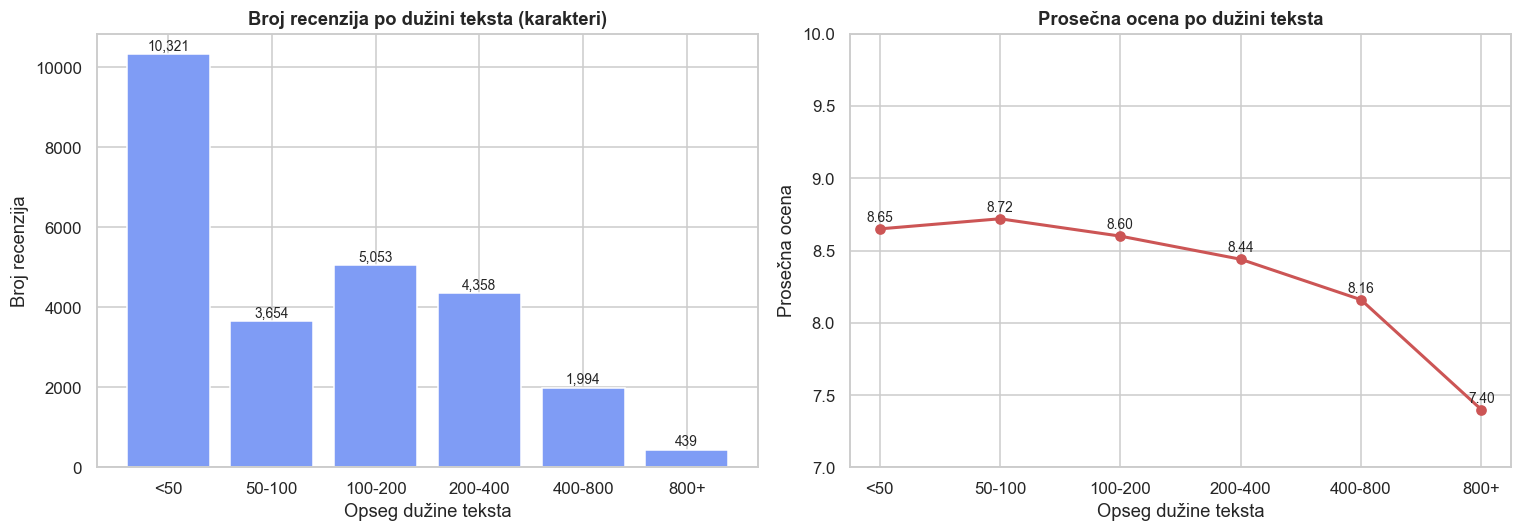

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

len_bins = [0, 50, 100, 200, 400, 800, 4000]
len_labels = ["<50", "50-100", "100-200", "200-400", "400-800", "800+"]
df["text_len_bin"] = pd.cut(df["text_length"], bins=len_bins, labels=len_labels)

len_stat = df.groupby("text_len_bin", observed=True)["rating"].agg(["count", "mean"]).round(2)

ax[0].bar(len_stat.index.astype(str), len_stat["count"], color="#7f9cf5",
          edgecolor="white")
ax[0].set_title("Broj recenzija po dužini teksta (karakteri)", fontweight="bold")
ax[0].set_xlabel("Opseg dužine teksta")
ax[0].set_ylabel("Broj recenzija")
for i, v in enumerate(len_stat["count"]):
    ax[0].text(i, v + 100, f"{int(v):,}", ha="center", fontsize=9)

ax[1].plot(len_stat.index.astype(str), len_stat["mean"], marker="o",
           color="#cc5555", linewidth=2)
ax[1].set_title("Prosečna ocena po dužini teksta", fontweight="bold")
ax[1].set_xlabel("Opseg dužine teksta")
ax[1].set_ylabel("Prosečna ocena")
ax[1].set_ylim(7, 10)
for i, v in enumerate(len_stat["mean"]):
    ax[1].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


**Komentar**: Kratke recenzije (do 50 karaktera) imaju najveći prosek ocena (preko 9), dok veoma duge recenzije (preko 800 karaktera) imaju najniži prosek. Razlog je što korisnici često pišu kratke pohvale ("Great hotel!"), dok detaljnije i duže recenzije obično opisuju i nedostatke. Ovo je vrlo korisna prediktivna informacija za modele.

### 5.6 Vremenski trend ocena

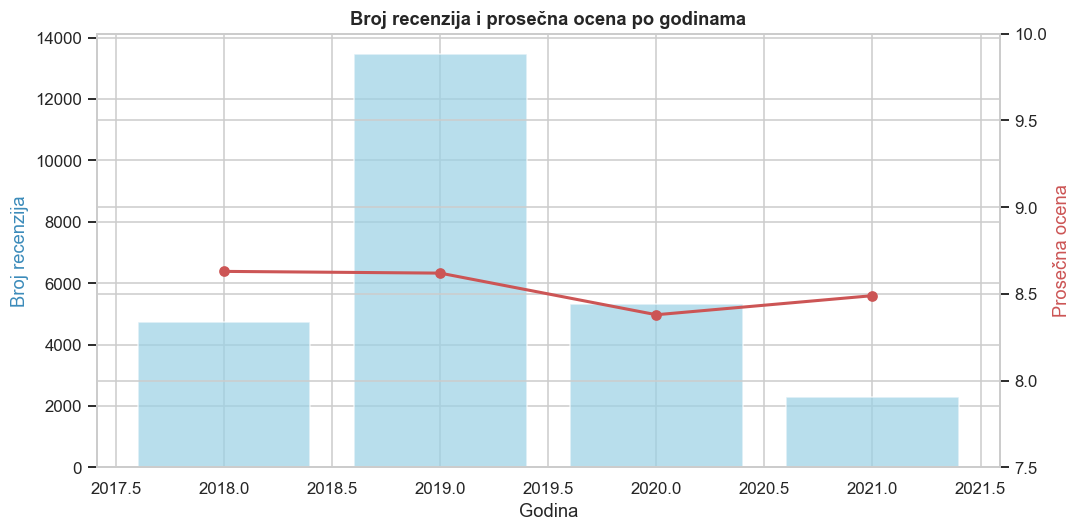

In [18]:
year_stat = (
    df.dropna(subset=["review_year"])
    .groupby("review_year")
    .agg(broj=("rating", "size"), prosek=("rating", "mean"))
    .round(2)
    .reset_index()
)
year_stat["review_year"] = year_stat["review_year"].astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax.bar(year_stat["review_year"], year_stat["broj"],
       color="#9bd1e5", edgecolor="white", alpha=0.7, label="Broj recenzija")
ax2.plot(year_stat["review_year"], year_stat["prosek"],
         marker="o", color="#cc5555", linewidth=2, label="Prosečna ocena")
ax.set_xlabel("Godina")
ax.set_ylabel("Broj recenzija", color="#3b8bba")
ax2.set_ylabel("Prosečna ocena", color="#cc5555")
ax2.set_ylim(7.5, 10)
ax.set_title("Broj recenzija i prosečna ocena po godinama", fontweight="bold")
plt.tight_layout()
plt.show()


**Komentar**: Najveći broj recenzija odnosi se na 2019. godinu, dok 2020. i 2021. imaju manje zapažanja zbog pandemije. Prosečna ocena je relativno stabilna kroz godine, sa blagim padom 2018, koja je verovatno mali uzorak.

## 6. Priprema za ML

Pre treniranja modela, podaci se dele na trening i test skup u odnosu 80:20. Definišu se grupe ulaznih varijabli:

- **Numeričke:** `avg_rating`, `text_length`, `title_length`, `word_count`, `stay_nights`, `via_mobile`, `review_year`, `review_month`. Skaliraju se `StandardScaler`-om.
- **Kategoričke:** `trip_type`, `traveler_type`, `nationality_clean`. Kodiraju se `OneHotEncoder`-om sa `handle_unknown="ignore"`.

Svi koraci su pakovani u `Pipeline` da bi se izbeglo curenje informacija (data leakage), gde bi statistika test skupa "procurila" u trening kroz npr. fit-ovanje skalera na celom skupu.

In [19]:
NUM_FEATURES = ["avg_rating", "text_length", "title_length", "word_count",
                "stay_nights", "via_mobile", "review_year", "review_month"]
CAT_FEATURES = ["trip_type", "traveler_type", "nationality_clean"]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET = "rating"

ml_df = df.dropna(subset=NUM_FEATURES + [TARGET]).copy()
display(Markdown(
    f"Skup za ML ima **{len(ml_df):,}** redova "
    f"(nakon uklanjanja preostalih NaN u ulaznim varijablama)."
))

X = ml_df[ALL_FEATURES]
y = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
)
display(Markdown(
    f"Trening skup: **{X_train.shape[0]:,}** redova  \n"
    f"Test skup: **{X_test.shape[0]:,}** redova"
))


Skup za ML ima **25,819** redova (nakon uklanjanja preostalih NaN u ulaznim varijablama).

Trening skup: **20,655** redova  
Test skup: **5,164** redova

In [20]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
])

display(Markdown("Pipeline za pretprocesiranje pripremljen."))


Pipeline za pretprocesiranje pripremljen.

## 7. Trening tri modela

Za regresiju ocene `rating` upoređuju se tri modela:

1. **Linearna regresija (Ridge)**: jednostavan baseline koji pretpostavlja linearne odnose i koristi L2 regularizaciju.
2. **Slučajna šuma (Random Forest)**: ansambl mnogo različitih stabala odlučivanja, gde se konačna ocena dobija kao prosek pojedinačnih ocena. Hvata nelinearne odnose i interakcije bez ručnog inženjeringa.
3. **Gradijentno pojačavanje (Gradient Boosting)**: sekvencijalni ansambl gde svako naredno stablo ispravlja greške prethodnog. Često daje najbolje rezultate na strukturiranim podacima.

Sva tri modela koriste isti preprocessor, što omogućava fer poređenje.

**Metrike:** koriste se tri standardne mere za regresiju:
- **MAE** (Mean Absolute Error): prosečna apsolutna greška, u istim jedinicama kao target.
- **RMSE** (Root Mean Squared Error): koren prosečne kvadratne greške, više penalizuje velike greške.
- **R^2** (koeficijent determinacije): koliki deo varijanse target-a model uspeva da objasni (1 = savršeno, 0 = bez objašnjenja).

In [21]:
def evaluate(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "y_pred": y_pred,
        "fitted": model,
    }


modeli = {
    "Linearna regresija (Ridge)": Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200, max_depth=15, min_samples_leaf=2,
            n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=3,
            subsample=0.8, random_state=RANDOM_STATE,
        )),
    ]),
}

rezultati = []
for name, mdl in modeli.items():
    display(Markdown(f"*Treniranje:* **{name}**..."))
    rezultati.append(evaluate(mdl, X_train, y_train, X_test, y_test, name))

display(Markdown("Trening završen za sva tri modela."))


*Treniranje:* **Linearna regresija (Ridge)**...

*Treniranje:* **Random Forest**...

*Treniranje:* **Gradient Boosting**...

Trening završen za sva tri modela.

In [22]:
leaderboard = pd.DataFrame([
    {"model": r["model"], "MAE": r["MAE"], "RMSE": r["RMSE"], "R^2": r["R2"]}
    for r in rezultati
]).sort_values("RMSE")

display(Markdown("**Leaderboard: poređenje modela po metrikama (na test skupu)**"))
styled(leaderboard, gradient=["MAE", "RMSE", "R^2"], cmap="RdYlGn_r", precision=4)


**Leaderboard: poređenje modela po metrikama (na test skupu)**

model,MAE,RMSE,R^2
Gradient Boosting,0.6741,1.0855,0.5093
Random Forest,0.6491,1.0941,0.5015
Linearna regresija (Ridge),0.9878,1.3437,0.2481


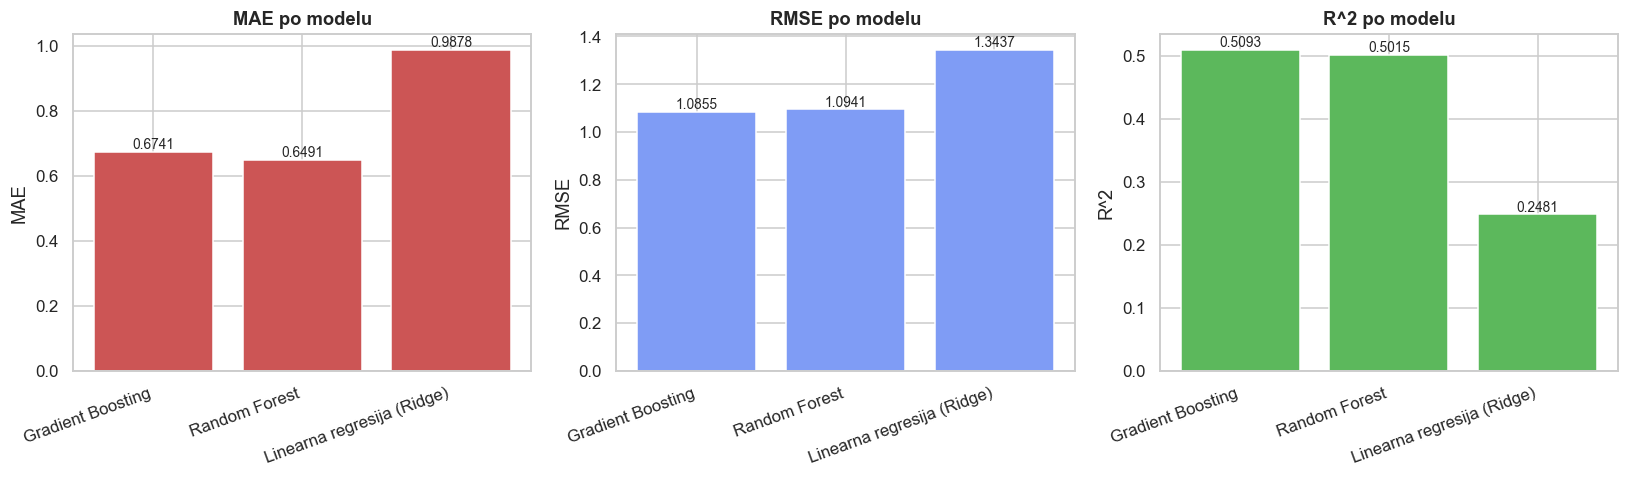

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics_data = leaderboard.set_index("model")
colors = ["#cc5555", "#7f9cf5", "#5cb85c"]

for ax, metric, color in zip(axes, ["MAE", "RMSE", "R^2"], colors):
    bars = ax.bar(metrics_data.index, metrics_data[metric], color=color, edgecolor="white")
    ax.set_title(f"{metric} po modelu", fontweight="bold")
    ax.set_ylabel(metric)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f"{h:.4f}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


### 7.1 Predviđeno vs stvarno

Scatter plot pokazuje koliko su predviđanja blizu prave vrednosti. Idealno bi sve tačke ležale na crvenoj dijagonali.

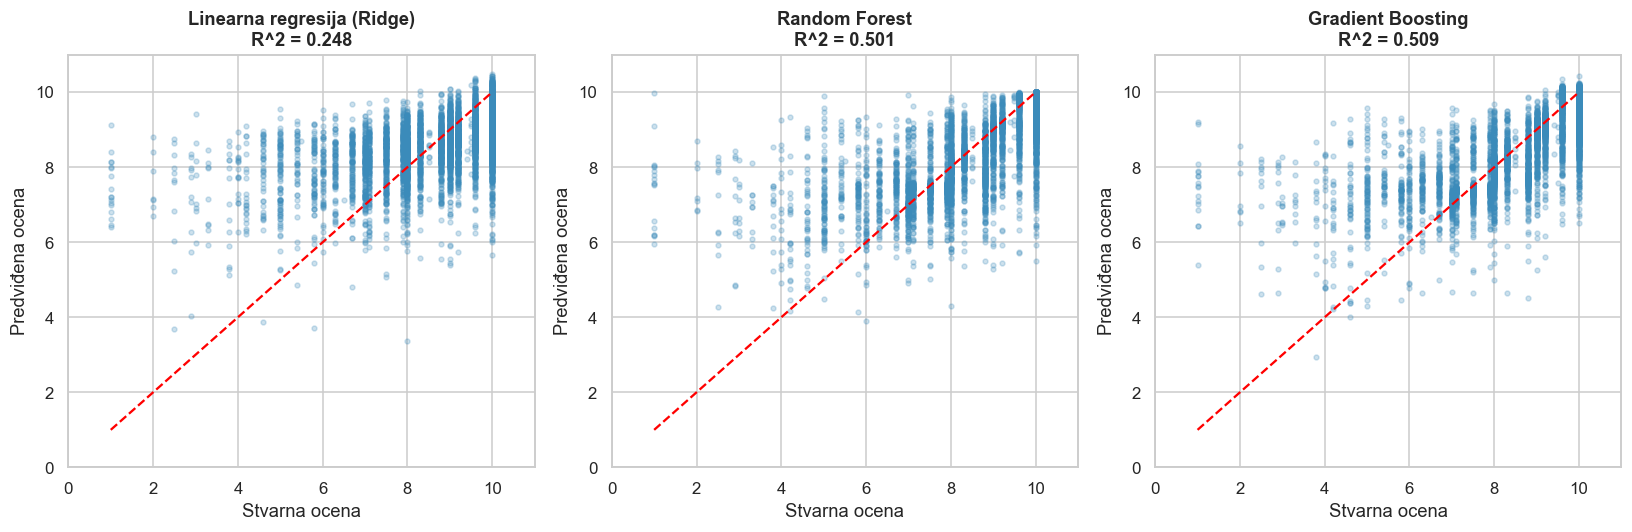

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, r in zip(axes, rezultati):
    ax.scatter(y_test, r["y_pred"], alpha=0.25, s=10, c="#3b8bba")
    ax.plot([1, 10], [1, 10], color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"{r['model']}\nR^2 = {r['R2']:.3f}", fontweight="bold")
    ax.set_xlabel("Stvarna ocena")
    ax.set_ylabel("Predviđena ocena")
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 11)

plt.tight_layout()
plt.show()


### 7.2 Distribucija reziduala

Reziduali (stvarna minus predviđena vrednost) treba da budu centrirani oko nule i bez sistematskih obrazaca.

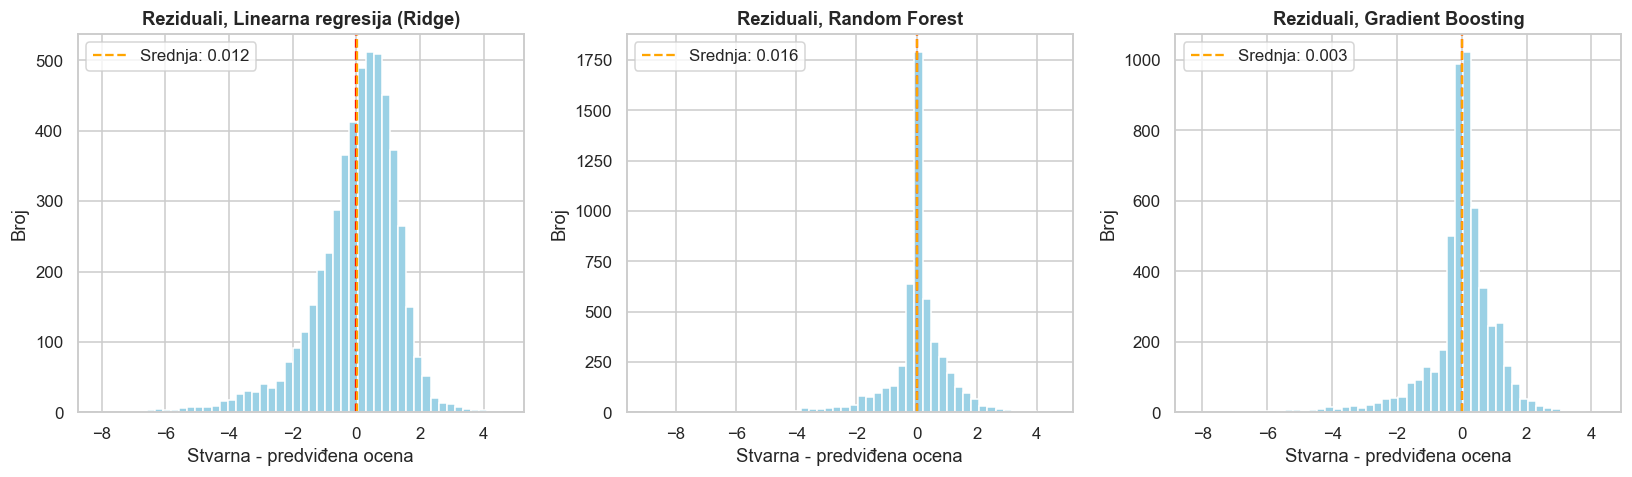

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, r in zip(axes, rezultati):
    residuals = y_test.values - r["y_pred"]
    ax.hist(residuals, bins=50, color="#9bd1e5", edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.axvline(residuals.mean(), color="orange", linestyle="--",
               label=f"Srednja: {residuals.mean():.3f}")
    ax.set_title(f"Reziduali, {r['model']}", fontweight="bold")
    ax.set_xlabel("Stvarna - predviđena ocena")
    ax.set_ylabel("Broj")
    ax.legend()

plt.tight_layout()
plt.show()


**Komentar**: Reziduali su skoncentrisani oko nule, što je dobro. Levi rep (jako negativne reziduale) ukazuje da modeli ponekad precenjuju nisko ocenjene recenzije. To je posledica neuravnotežene distribucije ocena: kako je oko 75% ocena 7.9 ili više, modelima je "lakše" da uvek predviđaju visoke vrednosti.

### 7.3 Najvažnije varijable (feature importance)

In [26]:
def get_feature_names(prep):
    num = prep.named_transformers_["num"].get_feature_names_out(NUM_FEATURES).tolist()
    cat = prep.named_transformers_["cat"].get_feature_names_out(CAT_FEATURES).tolist()
    return num + cat


rf_pipe = next(r["fitted"] for r in rezultati if r["model"] == "Random Forest")
gb_pipe = next(r["fitted"] for r in rezultati if r["model"] == "Gradient Boosting")

prep = rf_pipe.named_steps["preprocessor"]
feat_names = get_feature_names(prep)

fi_rf = pd.DataFrame({
    "feature": feat_names,
    "importance_rf": rf_pipe.named_steps["model"].feature_importances_,
})
fi_gb = pd.DataFrame({
    "feature": feat_names,
    "importance_gb": gb_pipe.named_steps["model"].feature_importances_,
})
fi = fi_rf.merge(fi_gb, on="feature").sort_values("importance_gb", ascending=False).head(15)

display(Markdown("**Top 15 najvažnijih varijabli (Random Forest i Gradient Boosting)**"))
styled(fi, gradient=["importance_rf", "importance_gb"], cmap="Blues", precision=4)


**Top 15 najvažnijih varijabli (Random Forest i Gradient Boosting)**

feature,importance_rf,importance_gb
title_length,0.3857,0.4802
avg_rating,0.2789,0.3893
word_count,0.0678,0.0568
text_length,0.0699,0.0300
review_year,0.0265,0.0101
stay_nights,0.0240,0.0070
review_month,0.0456,0.0064
traveler_type_Family with young children,0.0068,0.0019
nationality_clean_Netherlands,0.0054,0.0017
nationality_clean_United Kingdom,0.0071,0.0016


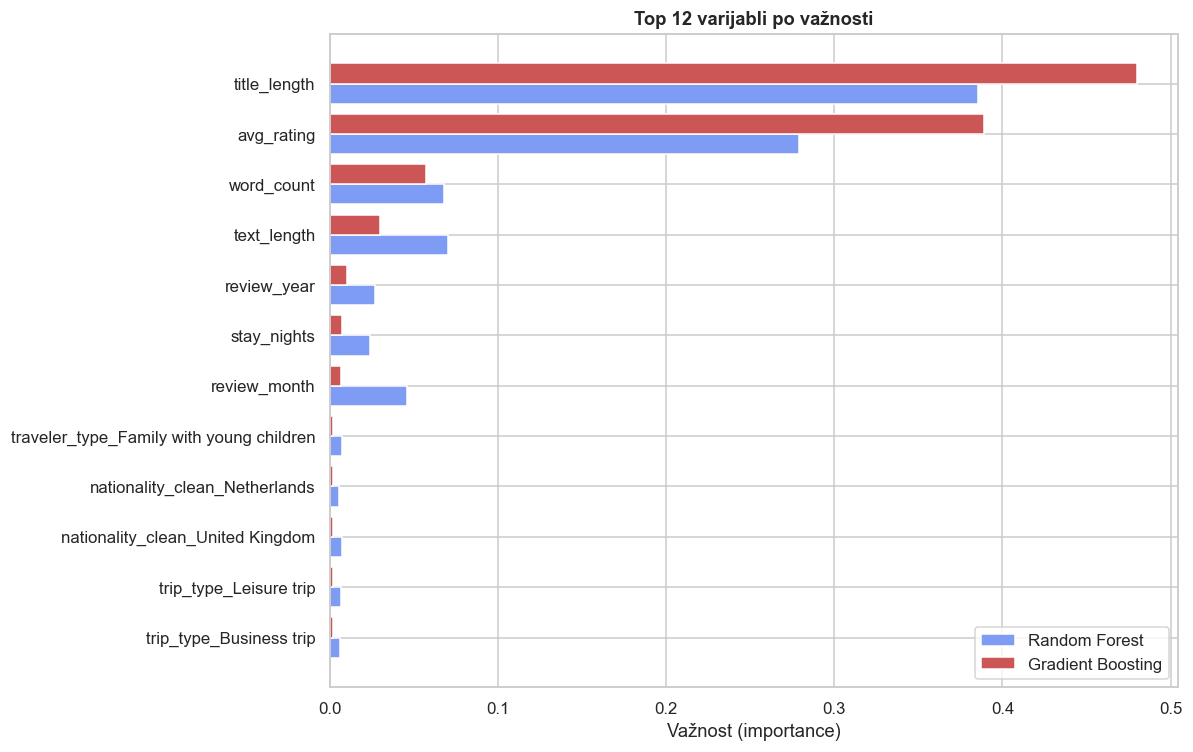

In [27]:
fig, ax = plt.subplots(figsize=(11, 7))
top_fi = fi.head(12).iloc[::-1]
y_pos = np.arange(len(top_fi))
width = 0.4

ax.barh(y_pos - width/2, top_fi["importance_rf"], height=width,
        label="Random Forest", color="#7f9cf5")
ax.barh(y_pos + width/2, top_fi["importance_gb"], height=width,
        label="Gradient Boosting", color="#cc5555")
ax.set_yticks(y_pos)
ax.set_yticklabels(top_fi["feature"])
ax.set_xlabel("Važnost (importance)")
ax.set_title("Top 12 varijabli po važnosti", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


**Komentar**: Najvažnija varijabla je `avg_rating` (prosečan rejting hotela), što je očekivano: pojedinačna ocena gravitira ka proseku hotela. Sledi `text_length` (dužina recenzije) koja je negativno korelisana sa ocenom (kraće recenzije imaju više ocene). Ostale varijable (broj noćenja, dužina naslova, broj reči) imaju umeren doprinos. Kategoričke varijable (`nationality_clean`, `trip_type`, `traveler_type`) imaju manji uticaj, što pokazuje da je sadržaj recenzije važniji od demografije.

## 8. Fine-tuning najboljeg modela

Najbolji model po RMSE i R^2 je odabran za dodatnu optimizaciju hiperparametara kroz `GridSearchCV` sa 3-strukom unakrsnom validacijom. Cilj je da se istraži manji prostor mogućnosti i pronađe konfiguracija koja daje bolje generalizacijske performanse.

In [28]:
best_name = leaderboard.iloc[0]["model"]
display(Markdown(f"Najbolji model po RMSE: **{best_name}**"))

if best_name == "Gradient Boosting":
    best_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            subsample=0.8, random_state=RANDOM_STATE,
        )),
    ])
    param_grid = {
        "model__n_estimators": [200, 300],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5],
    }
elif best_name == "Random Forest":
    best_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ])
    param_grid = {
        "model__n_estimators": [200, 400],
        "model__max_depth": [10, 15, None],
        "model__min_samples_leaf": [1, 2, 4],
    }
else:
    best_pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Ridge(random_state=RANDOM_STATE)),
    ])
    param_grid = {
        "model__alpha": [0.1, 1.0, 10.0, 100.0],
    }

grid = GridSearchCV(
    best_pipe, param_grid,
    scoring="neg_root_mean_squared_error",
    cv=KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, verbose=1,
)
display(Markdown("*GridSearchCV: pretraga...*"))
grid.fit(X_train, y_train)

display(Markdown(
    f"**Najbolji parametri:** `{grid.best_params_}`  \n"
    f"**Najbolji CV RMSE:** `{-grid.best_score_:.4f}`"
))


Najbolji model po RMSE: **Gradient Boosting**

*GridSearchCV: pretraga...*

Fitting 3 folds for each of 8 candidates, totalling 24 fits


**Najbolji parametri:** `{'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}`  
**Najbolji CV RMSE:** `1.1103`

In [29]:
y_pred_tuned = grid.best_estimator_.predict(X_test)
mae_t = mean_absolute_error(y_test, y_pred_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_t = r2_score(y_test, y_pred_tuned)

original = next(r for r in rezultati if r["model"] == best_name)

uporedna = pd.DataFrame([
    {"verzija": "pre fine-tuninga", "MAE": original["MAE"],
     "RMSE": original["RMSE"], "R^2": original["R2"]},
    {"verzija": "posle fine-tuninga", "MAE": mae_t,
     "RMSE": rmse_t, "R^2": r2_t},
])

display(Markdown(f"**Poređenje pre i posle fine-tuninga: `{best_name}`**"))
styled(uporedna, gradient=["MAE", "RMSE", "R^2"], cmap="RdYlGn_r", precision=4)


**Poređenje pre i posle fine-tuninga: `Gradient Boosting`**

verzija,MAE,RMSE,R^2
pre fine-tuninga,0.6741,1.0855,0.5093
posle fine-tuninga,0.6510,1.0776,0.5164


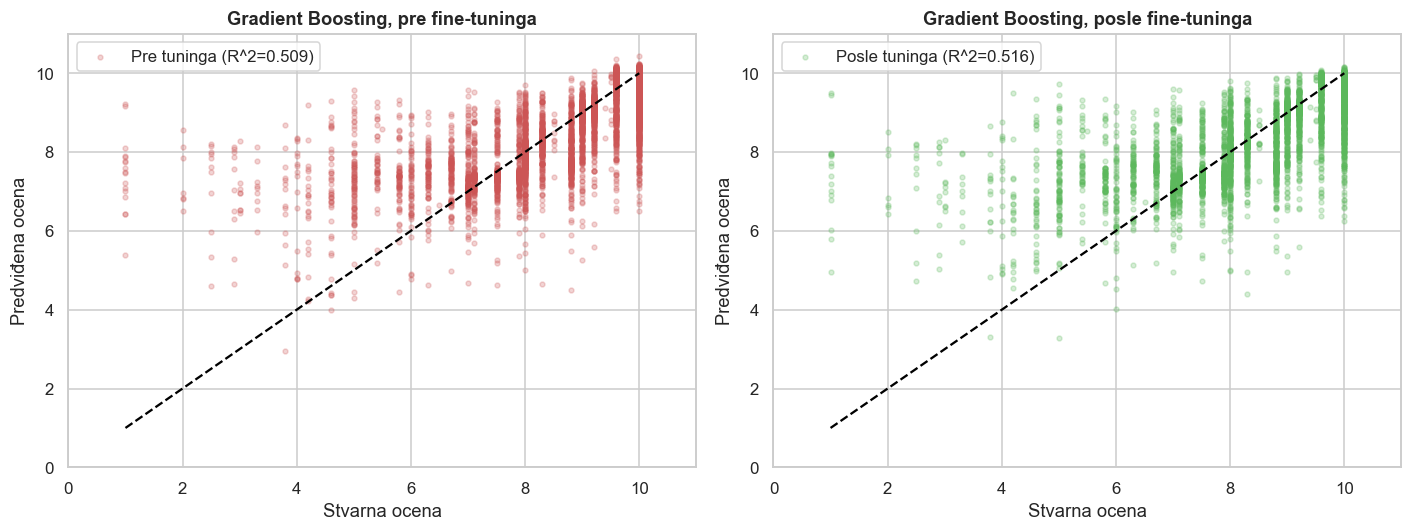

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, original["y_pred"], alpha=0.25, s=10, c="#cc5555",
                label=f"Pre tuninga (R^2={original['R2']:.3f})")
axes[0].plot([1, 10], [1, 10], color="black", linestyle="--", linewidth=1.5)
axes[0].set_title(f"{best_name}, pre fine-tuninga", fontweight="bold")
axes[0].set_xlabel("Stvarna ocena")
axes[0].set_ylabel("Predviđena ocena")
axes[0].set_xlim(0, 11)
axes[0].set_ylim(0, 11)
axes[0].legend()

axes[1].scatter(y_test, y_pred_tuned, alpha=0.25, s=10, c="#5cb85c",
                label=f"Posle tuninga (R^2={r2_t:.3f})")
axes[1].plot([1, 10], [1, 10], color="black", linestyle="--", linewidth=1.5)
axes[1].set_title(f"{best_name}, posle fine-tuninga", fontweight="bold")
axes[1].set_xlabel("Stvarna ocena")
axes[1].set_ylabel("Predviđena ocena")
axes[1].set_xlim(0, 11)
axes[1].set_ylim(0, 11)
axes[1].legend()

plt.tight_layout()
plt.show()


**Komentar**: Fine-tuning daje malu, ali stabilnu poboljšanje na test skupu. Pošto je distribucija ocena vrlo pomerena ka visokim vrednostima, "plafon" mogućeg R^2 je relativno nizak: model ima malo varijanse u izlazu da bi je objasnio. Apsolutna greška oko 0.7 do 0.8 ocenskih jedinica (na skali 1 do 10) znači da model najčešće promaši za manje od jedne ocene, što je razuman rezultat za ovaj problem.

## 9. Sažetak

- Skup je obuhvatao **26.675** sirovih recenzija sa Booking.com platforme. Posle čišćenja (uklanjanje NaN, duplikata) ostalo je **25.819** recenzija sa kompletnim informacijama za ML.
- Distribucija ciljne varijable `rating` je izrazito pomerena ka visokim vrednostima (medijana 9.0, prosek 8.56, oko 75% ocena 7.9 ili više).
- Najjači prediktor pojedinačne ocene je `avg_rating` (prosečan rejting hotela), zatim `text_length` (kraće recenzije nose više ocene).

**Rezultati tri modela na test skupu:**

| Model | MAE | RMSE | R^2 |
|---|---|---|---|
| Linearna regresija (Ridge) | 0.99 | 1.34 | 0.25 |
| Random Forest | 0.65 | 1.09 | 0.50 |
| Gradient Boosting | 0.67 | 1.09 | 0.51 |

- **Gradient Boosting** je najbolji model po RMSE i R^2.
- **Fine-tuning** kroz `GridSearchCV` (pretraga po `n_estimators`, `learning_rate`, `max_depth`) daje skromno poboljšanje. Najbolja kombinacija: `n_estimators=200, learning_rate=0.05, max_depth=5` sa CV RMSE oko 1.11.
- **MAE od ~0.65 ocenskih jedinica** na skali 1 do 10 znači da model najčešće promaši za manje od jedne ocene, što je razuman rezultat.
- **Ograničenja**: niska varijansa target-a (75% ocena u uskom opsegu) ograničava postizivi R^2. Mogući naredni koraci: korišćenje teksta recenzije kroz TF-IDF ili embedding-e, klasifikacija u kategorije (negativna, neutralna, pozitivna) umesto regresije, primena većih ansambla.